In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV

In [2]:
ed = pd.read_excel('/Users/elysa/Downloads/DAT 490 EDA Sheets Combined.xlsx', sheet_name = "2021 ED Combo Data")

In [3]:
ed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4272 entries, 0 to 4271
Columns: 189 entries, oshpd_id to ed_STATIONS_ON_1231
dtypes: float64(163), int64(3), object(23)
memory usage: 6.2+ MB


In [4]:
ed = ed[ed["Category"] == "All ED Visits"]

In [5]:
ed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 1 to 493
Columns: 189 entries, oshpd_id to ed_STATIONS_ON_1231
dtypes: float64(163), int64(3), object(23)
memory usage: 366.6+ KB


In [6]:
import re

# Paste cols from Excel Sheet
raw_cols = r"""
disp_Acute_Care disp_Against_Medical_Advice disp_Childrens_or_Cancer disp_Died
disp_Home_Health_Service disp_Invalid_Blank disp_Not_Defined_Elsewhere
disp_Prison_Jail disp_Psychiatric_Care disp_Residential_Care disp_Routine
disp_SN_IC_Care Medi_Cal Medicare Other_Payer Private_Coverage SelfPay
Zip_CA_Resident Zip_Foreign Zip_Homeless Zip_Out_of_State Sex_Female Sex_Male
Sex_Other_Unknown Age_0_09 Age_10_19 Age_20_29 Age_30_39 Age_40_49 Age_50_59
Age_60_69 Age_70_79 Age_80_ Age_Other_Unknown racegrp_aman racegrp_asian
racegrp_black racegrp_multirace racegrp_nhpi racegrp_other racegrp_unknown
racegrp_white eth_Hispanic eth_NonHispanic eth_Other_Unknown All_Other_Languages
English PLS_Other_Unknown Spanish dx_Circulatory dx_Digestive
dx_Diseases_of_the_Blood dx_Ear dx_Endocrine dx_Eye dx_Factors_Influencing_Health
dx_Genitourinary dx_Infectious dx_Injury_Poisoning dx_MentalHealth
dx_Musculoskeletal dx_Neoplasms dx_Nervous_System dx_Other_Unknown
dx_Pregnancy_Childbirth dx_Respiratory dx_Skin dx_Symptoms_Signs_NEC
disp_CAH disp_Hospice_Care disp_Rehab Zip_Unknown dx_Certain_Perinatal_Conditions
dx_Congenital disp_Other Zip_Blank_Invalid Unknown_inv_Payer disp_Disaster_Care_Site
a_disp_Acute_Care a_disp_Against_Medical_Advice a_disp_Died a_disp_Home_Health_Service
a_disp_Hospice_Care a_disp_Psychiatric_Care a_disp_Rehab a_disp_Residential_Care
a_disp_Routine a_disp_SN_IC_Care a_Medi_Cal a_Medicare a_Other_Payer a_Private_Coverage
a_SelfPay a_Zip_CA_Resident a_Zip_Foreign a_Zip_Homeless a_Zip_Out_of_State a_Sex_Female
a_Sex_Male a_Age_20_29 a_Age_30_39 a_Age_40_49 a_Age_50_59 a_Age_60_69 a_Age_70_79
a_Age_80_ a_Age_Other_Unknown a_racegrp_asian a_racegrp_black a_racegrp_multirace
a_racegrp_other a_racegrp_unknown a_racegrp_white a_Eth_Other_Unknown a_eth_Hispanic
a_eth_NonHispanic a_All_Other_Languages a_English a_PLS_Other_Unknown a_Spanish
a_dx_Circulatory a_dx_Digestive a_dx_Diseases_of_the_Blood a_dx_Ear a_dx_Endocrine
a_dx_Genitourinary a_dx_Infectious a_dx_Injury_Poisoning a_dx_MentalHealth
a_dx_Musculoskeletal a_dx_Neoplasms a_dx_Nervous_System a_dx_Other_Unknown
a_dx_Respiratory a_dx_Skin a_dx_Symptoms_Signs_NEC a_disp_Childrens_or_Cancer
a_disp_Not_Defined_Elsewhere a_disp_Prison_Jail a_Zip_Unknown a_Age_10_19 a_racegrp_aman
a_racegrp_nhpi a_dx_Congenital a_dx_Eye a_dx_Factors_Influencing_Health
a_dx_Pregnancy_Childbirth a_disp_CAH a_Age_0_09 a_dx_Certain_Perinatal_Condition
a_Zip_Blank_Invalid a_sex_Oth_Unknown a_Unknown_inv_Payer a_disp_Other
a_disp_Invalid_Blank a_disp_Disaster_Care_Site
"""

# Assign columns to col list
count_cols = [c for c in re.split(r"[\s,]+", raw_cols.strip()) if c]

# impute 0s
ed[count_cols] = ed[count_cols].apply(pd.to_numeric, errors="coerce").fillna(0)


In [7]:
# convert counts to proportion of total visits per hospital
prop = ed[count_cols].div(ed["NmbVsts"], axis=0)
prop.columns = [f"prop_{c}" for c in count_cols]

In [8]:
# Attach proportion columns
ed = pd.concat([ed, prop], axis=1)

# check per-row sums of proportions to 1
def check_group(prefixes):
    cols = [c for c in count_cols if any(c.startswith(p) for p in prefixes)]
    if not cols: 
        return
    s = ed[[f"prop_{c}" for c in cols]].sum(axis=1)
    print(f"{prefixes}: median={s.median():.3f}, IQR=[{s.quantile(0.25):.3f}, {s.quantile(0.75):.3f}]")

check_group(["disp_"])
check_group(["dx_"])
check_group(["Age_"])
check_group(["Sex_"])
check_group(["racegrp_"])
check_group(["eth_"])

['disp_']: median=1.000, IQR=[1.000, 1.000]
['dx_']: median=1.000, IQR=[1.000, 1.000]
['Age_']: median=1.000, IQR=[1.000, 1.000]
['Sex_']: median=1.000, IQR=[1.000, 1.000]
['racegrp_']: median=1.000, IQR=[1.000, 1.000]
['eth_']: median=1.000, IQR=[1.000, 1.000]


In [9]:
#keep only "All ED Visits"
df = ed.copy()
mask_all = df["Category"].astype(str).str.strip().str.lower().eq("all ed visits")
df_fac = df.loc[mask_all].copy()

# target: PCSA binary 
y = (df_fac["PrimaryCareShortageArea"].astype(str).map({"Yes":1, "No":0}))
keep = y.notna()
df_fac, y = df_fac.loc[keep].copy(), y.loc[keep].astype(int)

# all count features as proportions
prop_cols = [c for c in df_fac.columns if c.startswith("prop_")]
cat = ["BedSize", "HospitalOwnership", "TechingDesignation","CONTROL_TYPE_DESC", "ER_SERVICE_LEVEL_DESC" ]
cat_cols = [c for c in cat if c in df_fac.columns]


num_cols = prop_cols + ["Visits_Per_Station"] #already a proportion of ED stations

X = df_fac[num_cols + cat_cols].copy()


#Impute missing values with median for numeric and mode for categorical and scale
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler(with_mean=False))])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))])


pre = ColumnTransformer(transformers=[("num", numeric_transformer, num_cols),("cat", categorical_transformer, cat_cols),
    ],remainder="drop", verbose_feature_names_out=False,)


In [10]:
# Split data to train and evaluate sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

In [11]:
base_model = RandomForestClassifier(n_estimators=400, max_depth=None, min_samples_split=2, min_samples_leaf=1,
                                    class_weight="balanced", random_state=0, n_jobs=-1)

pipe = Pipeline(steps=[("pre", pre), ("clf", base_model)])

param_grid = {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 10, 20], 
              "clf__min_samples_split": [2, 5],"clf__min_samples_leaf": [1, 2, 5]}

# CV + ROC-AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
gcv = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, refit=True, verbose=0)

# Fit on on training data
gcv.fit(X_train, y_train)

# Use the best model
pipe = gcv.best_estimator_
print("Best params:", gcv.best_params_)
print("CV best ROC AUC:", gcv.best_score_)


Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 400}
CV best ROC AUC: 0.8399736495388668


In [12]:
pipe.fit(X_train, y_train)
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f"Accuracy (pipe.score): {pipe.score(X_test, y_test):.3f}")


Accuracy (pipe.score): 0.800


<Figure size 600x500 with 0 Axes>

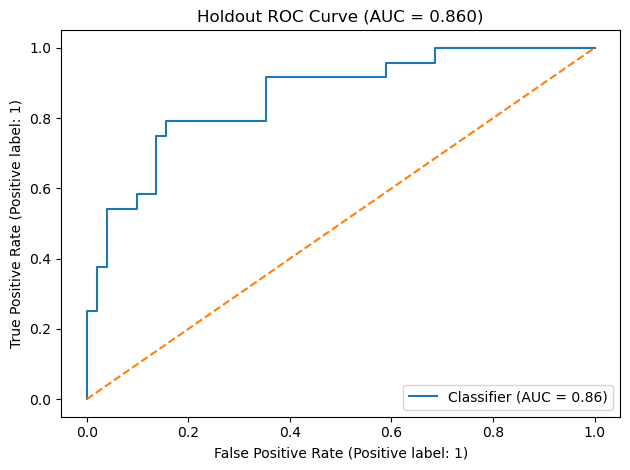

In [13]:
auc_val = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.plot([0, 1], [0, 1], linestyle="--")  # chance line
plt.title(f"Holdout ROC Curve (AUC = {auc_val:.3f})")
plt.tight_layout()
plt.show()


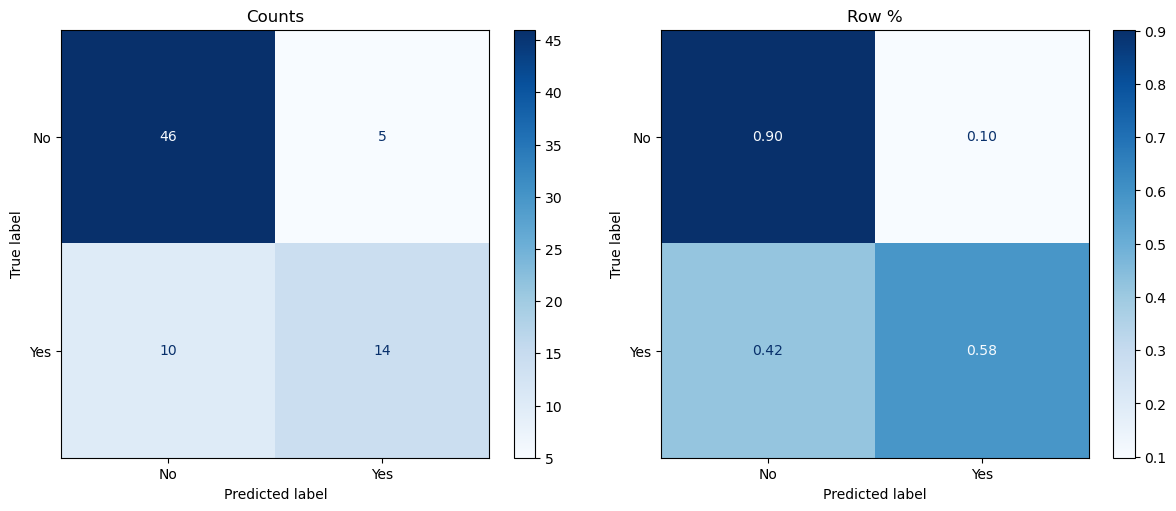

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[0,1], display_labels=["No","Yes"],
                                        ax=axes[0], cmap="Blues", normalize=None, values_format="d")
axes[0].set_title("Counts")
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[0,1], display_labels=["No","Yes"],
                                        ax=axes[1], cmap="Blues", normalize="true", values_format=".2f")
axes[1].set_title("Row %")
axes[1].grid(False)

plt.show()

In [15]:
sns.set_theme(style="whitegrid")
feature_names = pipe.named_steps["pre"].get_feature_names_out().tolist()
importances = pd.Series(pipe.named_steps["clf"].feature_importances_, index=feature_names)\
              .sort_values(ascending=False)
print("\nTop 20 feature importances (RF):")
print(importances.head(20))


Top 20 feature importances (RF):
prop_racegrp_asian                  0.026790
prop_a_racegrp_asian                0.026423
prop_a_All_Other_Languages          0.025292
prop_a_racegrp_black                0.023133
prop_a_racegrp_other                0.019736
prop_a_eth_Hispanic                 0.018921
prop_a_Private_Coverage             0.018907
prop_a_disp_Hospice_Care            0.017894
prop_a_Zip_CA_Resident              0.017026
prop_Age_80_                        0.016889
prop_a_disp_Home_Health_Service     0.016840
prop_a_disp_Rehab                   0.016690
prop_disp_Home_Health_Service       0.015429
prop_dx_Eye                         0.014794
prop_a_dx_Infectious                0.014762
prop_disp_Against_Medical_Advice    0.014754
prop_All_Other_Languages            0.014321
prop_a_Sex_Male                     0.013439
prop_Age_20_29                      0.011223
prop_racegrp_nhpi                   0.010918
dtype: float64


In [16]:
# RandomForest feature importances (top N)
def plot_rf_importances(pipe, topn=20):

    names = pipe.named_steps["pre"].get_feature_names_out().tolist()
    importances = pipe.named_steps["clf"].feature_importances_
    fi = pd.DataFrame({"feature": names,"importance": pipe.named_steps["clf"].feature_importances_}).sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(8, max(4, 0.4*len(fi))))
    sns.barplot(data=fi, x="importance", y="feature")
    plt.title(f"RandomForest: Top {len(fi)} feature importances")
    plt.xlabel("Importance"); plt.ylabel("")
    plt.tight_layout()
    plt.show()

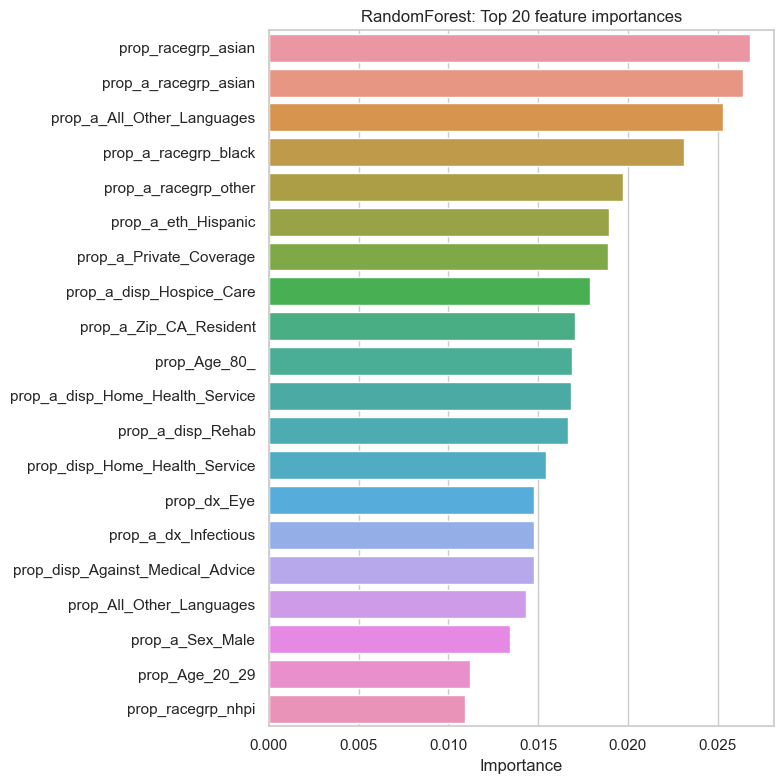

In [17]:
# After training:
plot_rf_importances(pipe)


In [18]:
print("Holdout ROC AUC:", roc_auc_score(y_test, y_prob).round(3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

# Cross-validated ROC AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
print("CV ROC AUC:", np.round(cv_auc, 3), "mean =", cv_auc.mean().round(3))


Holdout ROC AUC: 0.86
Confusion matrix:
 [[46  5]
 [10 14]]

Classification report:
               precision    recall  f1-score   support

           0      0.821     0.902     0.860        51
           1      0.737     0.583     0.651        24

    accuracy                          0.800        75
   macro avg      0.779     0.743     0.755        75
weighted avg      0.794     0.800     0.793        75

CV ROC AUC: [0.831 0.897 0.851 0.882 0.877] mean = 0.868


In [19]:
#Get the numeric columns from the pipeline- prop_ training set
def expected_raw_columns(pipe):
    return {name: list(cols) if not callable(cols) else [] for name, trans, cols in pipe.named_steps["pre"].transformers}

num_cols = expected_raw_columns(pipe)["num"]

# Build groups by prefixes within num_cols
def base(c): return c.removeprefix("prop_")
PAYERS = {"Medi_Cal","Medicare","Other_Payer","Private_Coverage","SelfPay","Unknown_inv_Payer"}
LANGS  = {"All_Other_Languages","English","PLS_Other_Unknown","Spanish"}

groups = {
    "disp":    [c for c in num_cols if base(c).startswith(("disp_","a_disp_"))],
    "dx":      [c for c in num_cols if base(c).startswith(("dx_","a_dx_"))],
    "payer":   [c for c in num_cols if base(c) in PAYERS or base(c).startswith(("a_Medi_Cal","a_Medicare","a_Other_Payer","a_Private_Coverage","a_SelfPay","a_Unknown_inv_Payer"))],
    "zip":     [c for c in num_cols if base(c).startswith(("Zip_","a_Zip_"))],
    "sex":     [c for c in num_cols if base(c).startswith(("Sex_","a_Sex_")) or base(c) in {"a_sex_Oth_Unknown"}],
    "age":     [c for c in num_cols if base(c).startswith(("Age_","a_Age_"))],
    "race":    [c for c in num_cols if base(c).startswith(("racegrp_","a_racegrp_"))],
    "eth":     [c for c in num_cols if base(c).startswith(("eth_","a_eth_")) or base(c) in {"a_Eth_Other_Unknown"}],
    "lang":    [c for c in num_cols if base(c) in LANGS or base(c).startswith(("a_All_Other_Languages","a_English","a_PLS_Other_Unknown","a_Spanish"))],
    "unknown": [c for c in num_cols if base(c) in {"Zip_Blank_Invalid","disp_Invalid_Blank"}],
}

In [20]:

# Check groups reference columns that exist in X_test
#present_check = {k: sum(c in X_test.columns for c in v) for k,v in groups.items()}
#print("Cols present per group:", present_check)

#Group permutation importance with 95% CIs, using the already-fitted pipe
def group_perm_importance(pipe, X_test, y_test, groups_dict, n_repeats=200, seed=0):
    rng = np.random.default_rng(seed)
    base_auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])
    rows = []
    for g, cols in groups_dict.items():
        cols = [c for c in cols if c in X_test.columns]
        if not cols:
            continue
        drops = []
        for _ in range(n_repeats):
            Xt = X_test.copy()
            # permute every column in the group
            for c in cols:
                Xt[c] = rng.permutation(Xt[c].values)
            auc = roc_auc_score(y_test, pipe.predict_proba(Xt)[:,1])
            drops.append(base_auc - auc)
        lo, hi = np.percentile(drops, [2.5, 97.5])
        rows.append({"group": g, "mean_drop": float(np.mean(drops)), "ci_lo": float(lo), "ci_hi": float(hi),
                     "n_cols": len(cols)})
    return pd.DataFrame(rows).sort_values("mean_drop", ascending=False)

gp_perm = group_perm_importance(pipe, X_test, y_test, groups, n_repeats=200)
print(gp_perm)

     group  mean_drop     ci_lo     ci_hi  n_cols
0     disp   0.010167 -0.013154  0.030249      34
1       dx   0.009714 -0.005739  0.026961      42
7      eth   0.007492 -0.000817  0.015523       6
5      age   0.006164 -0.006556  0.018811      20
2    payer   0.005715 -0.005719  0.017974      12
8     lang   0.003174 -0.010641  0.015523       8
3      zip   0.000245 -0.009007  0.008987      12
4      sex   0.000053 -0.007353  0.006536       6
6     race  -0.000976 -0.023693  0.022100      16
9  unknown  -0.001642 -0.003268  0.000000       2


In [21]:
def group_perm_distributions(pipe, X_test, y_test, groups, n_repeats=200, seed=0):
# Function return dict: group array of AUC drops from permuting that group's columns.
    rng = np.random.default_rng(seed)
    base_auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])
    dist = {}
    for g, cols in groups.items():
        cols = [c for c in cols if c in X_test.columns]
        if not cols:
            continue
        drops = []
        for _ in range(n_repeats):
            Xt = X_test.copy()
            for c in cols:
                Xt[c] = rng.permutation(Xt[c].values)
            auc = roc_auc_score(y_test, pipe.predict_proba(Xt)[:,1])
            drops.append(base_auc - auc)
        dist[g] = np.asarray(drops)
    return dist


/var/folders/7g/gblq5dw54b98ghbc1w_djjfm0000gn/T/ipykernel_42716/1772846901.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=labels, whis=(2.5,97.5), showfliers=False)


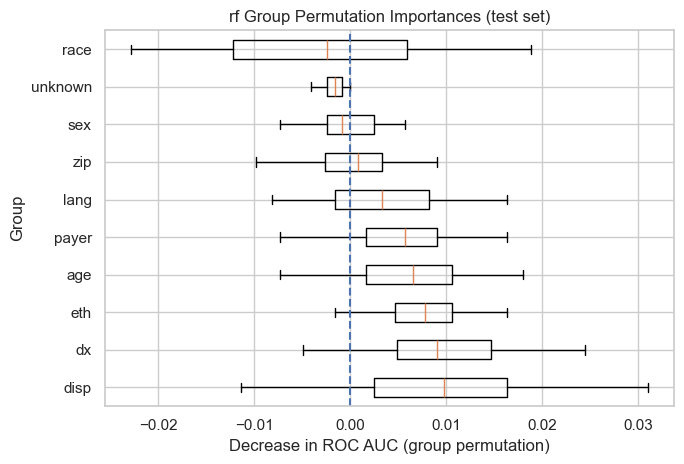

In [22]:

# Plot distribution of AUC drops as horizontal boxplots
def plot_group_perm_boxplots(dist, top_k=None, title= f"rf Group Permutation Importances (test set)"):
    items = sorted(dist.items(), key=lambda kv: kv[1].mean(), reverse=True)
    if top_k:
        items = items[:top_k]
    labels = [k for k,_ in items]
    data   = [v for _,v in items]

    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.boxplot(data, vert=False, labels=labels, whis=(2.5,97.5), showfliers=False)
    ax.axvline(0, linestyle="--")
    ax.set_xlabel("Decrease in ROC AUC (group permutation)")
    ax.set_ylabel("Group")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

dist = group_perm_distributions(pipe, X_test, y_test, groups, n_repeats=200, seed=1)
plot_group_perm_boxplots(dist, top_k=None)  
